Training with learning rate: 0.1
Validation Accuracy: 62.61%



C:\Users\Afnan Shahriar\AppData\Local\Temp\ipykernel_5532\3959857130.py:30: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


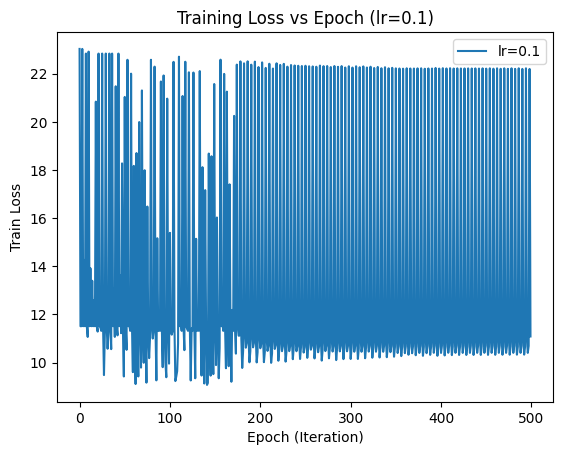

Training with learning rate: 0.01
Validation Accuracy: 57.39%



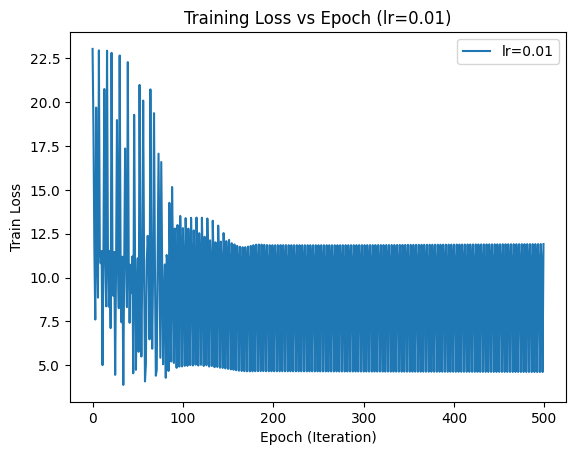

Training with learning rate: 0.001
Validation Accuracy: 58.26%



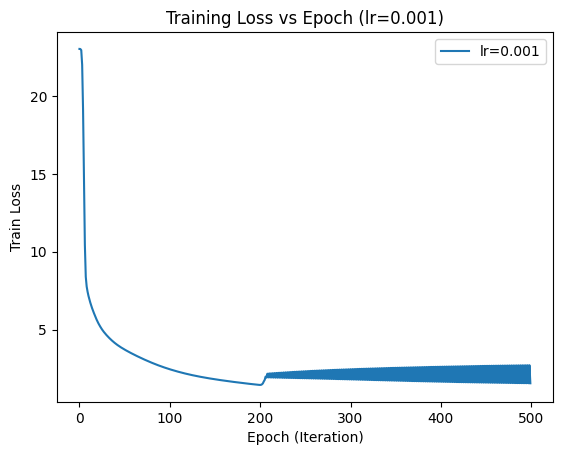

Training with learning rate: 0.0001
Validation Accuracy: 53.04%



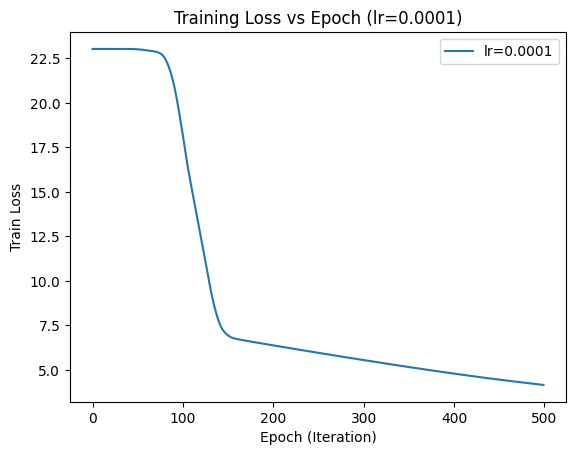

Best Learning Rate: 0.1
Calculating test accuracy...
Test Accuracy: 64.66%


In [11]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import csv

# Load dataset from CSV file
def load_data(filename):
    with open(filename, 'r') as f:
        reader = csv.reader(f)
        # Skip the header row
        next(reader)
        data = np.array(list(reader)).astype(float)
    return data

# Split data into training, validation, and test sets
def split_data(data):
    np.random.shuffle(data)  # Shuffle the data
    n_samples = data.shape[0]
    train_size = int(0.7 * n_samples)
    val_size = int(0.15 * n_samples)
    
    train_data = data[:train_size]
    val_data = data[train_size:train_size + val_size]
    test_data = data[train_size + val_size:]
    
    return train_data, val_data, test_data

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Train logistic regression model
def train_logistic_regression(train_data, lr=0.01, max_iter=500):
    X_train = train_data[:, :-1]  # Features
    y_train = train_data[:, -1]    # Labels
    
    # Concatenate 1 for bias term
    X_train = np.hstack((X_train, np.ones((X_train.shape[0], 1))))  
    
    n_features = X_train.shape[1]  # Number of features
    theta = np.random.uniform(0, 1, n_features)  # Random initialization of weights
    
    history = []  # To store the training loss history

    for itr in range(max_iter):
        z = np.dot(X_train, theta)  # Linear combination
        h = sigmoid(z)               # Sigmoid function
        
        # Calculate the cost
        J = - np.mean(y_train * np.log(h + 1e-15) + (1 - y_train) * np.log(1 - h + 1e-15))  # Add epsilon for numerical stability
        history.append(J)  # Record the cost

        # Gradient calculation
        dv = np.dot(X_train.T, (h - y_train)) / y_train.size  # Gradient of the loss
        theta -= lr * dv  # Update the weights

    return theta, history

# Validate the model and calculate accuracy
def validate_model(theta, validation_data):
    X_val = validation_data[:, :-1]
    y_val = validation_data[:, -1]
    
    # Concatenate 1 for bias term
    X_val = np.hstack((X_val, np.ones((X_val.shape[0], 1))))  
    
    z = np.dot(X_val, theta)  # Linear combination
    h = sigmoid(z)  # Sigmoid function
    predictions = (h >= 0.5).astype(int)  # Convert probabilities to binary predictions

    # Calculate accuracy
    accuracy = np.mean(predictions == y_val) * 100
    return accuracy

# Main function to run the logistic regression
def main():
    # Load dataset
    data = load_data('diabetes.csv')  # Change to your CSV filename
    
    # Split the dataset
    train_data, val_data, test_data = split_data(data)
    
    learning_rates = [0.1, 0.01, 0.001, 0.0001]
    results = []

    for lr in learning_rates:
        print(f"Training with learning rate: {lr}")
        theta, history = train_logistic_regression(train_data, lr=lr, max_iter=500)
        
        # Validate model and collect results
        val_acc = validate_model(theta, val_data)
        results.append((lr, val_acc))
        print(f"Validation Accuracy: {val_acc:.2f}%\n")

        # Plot training loss for this learning rate
        plt.figure()  # Create a new figure
        plt.plot(range(len(history)), history, label=f'lr={lr}')
        plt.title(f"Training Loss vs Epoch (lr={lr})")
        plt.xlabel("Epoch (Iteration)")
        plt.ylabel("Train Loss")
        plt.legend()
        plt.show()  # Show the current plot

    # Find the learning rate with maximum validation accuracy
    best_lr = max(results, key=lambda x: x[1])[0]
    print(f"Best Learning Rate: {best_lr}")
    
    # Calculate test accuracy with best learning rate
    print("Calculating test accuracy...")
    best_theta, _ = train_logistic_regression(train_data, lr=best_lr, max_iter=500)
    test_acc = validate_model(best_theta, test_data)
    print(f"Test Accuracy: {test_acc:.2f}%")

# Run the main function
if __name__ == "__main__":
    main()


Training with learning rate: 0.1
Validation Accuracy: 66.96%



C:\Users\Afnan Shahriar\AppData\Local\Temp\ipykernel_5532\415033310.py:32: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


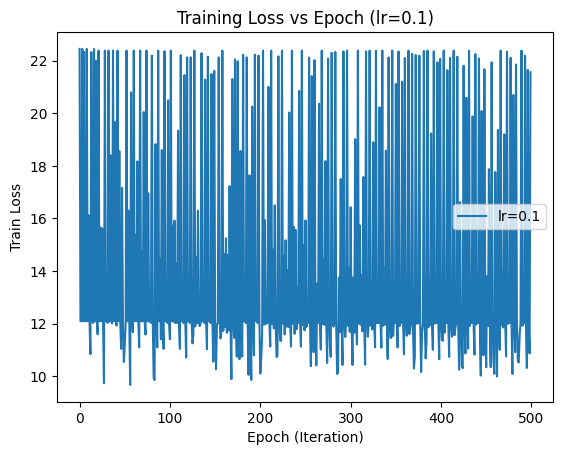

Training with learning rate: 0.01
Validation Accuracy: 71.30%



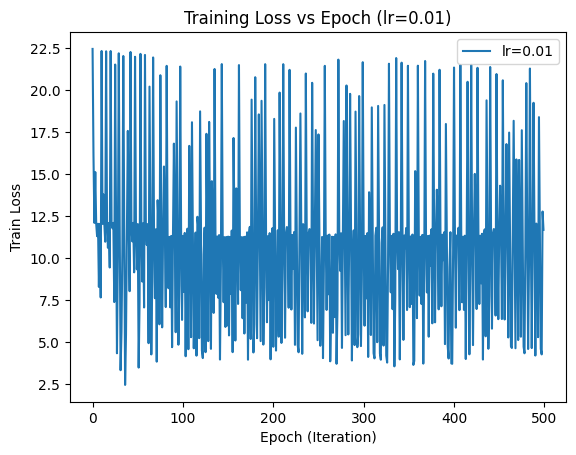

Training with learning rate: 0.001
Validation Accuracy: 38.26%



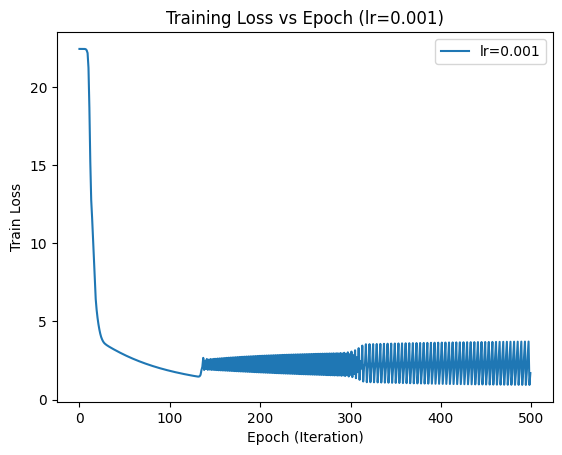

Training with learning rate: 0.0001
Validation Accuracy: 42.61%



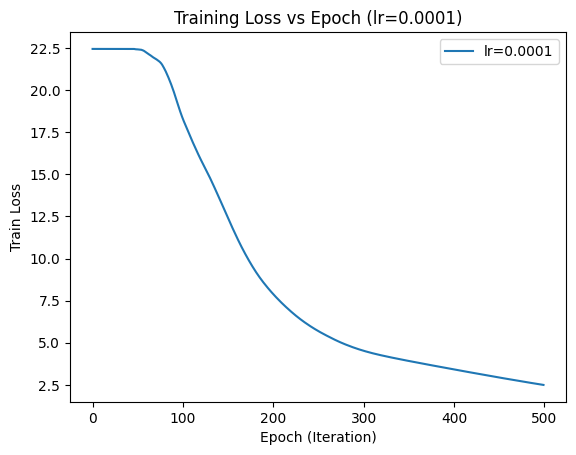

Best Learning Rate: 0.01
Calculating test accuracy...
Test Accuracy: 63.79%


In [10]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import csv

np.random.seed(80)

# Load dataset from CSV file
def load_data(filename):
    with open(filename, 'r') as f:
        reader = csv.reader(f)
        # Skip the header row
        next(reader)
        data = np.array(list(reader)).astype(float)
    return data

# Split data into training, validation, and test sets
def split_data(data):
    np.random.shuffle(data)  # Shuffle the data
    n_samples = data.shape[0]
    train_size = int(0.7 * n_samples)
    val_size = int(0.15 * n_samples)
    
    train_data = data[:train_size]
    val_data = data[train_size:train_size + val_size]
    test_data = data[train_size + val_size:]
    
    return train_data, val_data, test_data

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Train logistic regression model
def train_logistic_regression(train_data, lr=0.01, max_iter=500):
    X_train = train_data[:, :-1]  # Features
    y_train = train_data[:, -1]    # Labels
    
    # Concatenate 1 for bias term
    X_train = np.hstack((X_train, np.ones((X_train.shape[0], 1))))  
    
    n_features = X_train.shape[1]  # Number of features
    theta = np.random.uniform(0, 1, n_features)  # Random initialization of weights
    
    history = []  # To store the training loss history

    for itr in range(max_iter):
        z = np.dot(X_train, theta)  # Linear combination
        h = sigmoid(z)               # Sigmoid function
        
        # Calculate the cost
        J = - np.mean(y_train * np.log(h + 1e-15) + (1 - y_train) * np.log(1 - h + 1e-15))  # Add epsilon for numerical stability
        history.append(J)  # Record the cost

        # Gradient calculation
        dv = np.dot(X_train.T, (h - y_train)) / y_train.size  # Gradient of the loss
        theta -= lr * dv  # Update the weights

    return theta, history

# Validate the model and calculate accuracy
def validate_model(theta, validation_data):
    X_val = validation_data[:, :-1]
    y_val = validation_data[:, -1]
    
    # Concatenate 1 for bias term
    X_val = np.hstack((X_val, np.ones((X_val.shape[0], 1))))  
    
    z = np.dot(X_val, theta)  # Linear combination
    h = sigmoid(z)  # Sigmoid function
    predictions = (h >= 0.5).astype(int)  # Convert probabilities to binary predictions

    # Calculate accuracy
    accuracy = np.mean(predictions == y_val) * 100
    return accuracy

# Main function to run the logistic regression
def main():
    # Load dataset
    data = load_data('diabetes.csv')  # Change to your CSV filename
    
    # Split the dataset
    train_data, val_data, test_data = split_data(data)
    
    learning_rates = [0.1, 0.01, 0.001, 0.0001]
    results = []

    for lr in learning_rates:
        print(f"Training with learning rate: {lr}")
        theta, history = train_logistic_regression(train_data, lr=lr, max_iter=500)
        
        # Validate model and collect results
        val_acc = validate_model(theta, val_data)
        results.append((lr, val_acc))
        print(f"Validation Accuracy: {val_acc:.2f}%\n")

        # Plot training loss for this learning rate
        plt.figure()  # Create a new figure
        plt.plot(range(len(history)), history, label=f'lr={lr}')
        plt.title(f"Training Loss vs Epoch (lr={lr})")
        plt.xlabel("Epoch (Iteration)")
        plt.ylabel("Train Loss")
        plt.legend()
        plt.show()  # Show the current plot

    # Find the learning rate with maximum validation accuracy
    best_lr = max(results, key=lambda x: x[1])[0]
    print(f"Best Learning Rate: {best_lr}")
    
    # Calculate test accuracy with best learning rate
    print("Calculating test accuracy...")
    best_theta, _ = train_logistic_regression(train_data, lr=best_lr, max_iter=500)
    test_acc = validate_model(best_theta, test_data)
    print(f"Test Accuracy: {test_acc:.2f}%")

# Run the main function
if __name__ == "__main__":
    main()
